# Interpreting Chemprop Predictions with Myerson Values

[Myerson values](https://doi.org/10.1007%2F978-3-540-24790-6_2) are a solution concept similar to the Shapley value from cooperative game theory. By treating a graph neural network (such as chemprops MPNN) as the payoff function of a game, we can assign each player of the game (each node in a graph) its contribution to the payoff, i.e. its contribution to the final prediction.

The [`myerson`](https://myerson.readthedocs.io) python package can be used to calculate Myerson values or approximate them using Monte Carlo sampling (as the calculation times become infeasible for larger graphs).

We'll have a look at a toy example in this notebook, to see if a model is able to recognize a hydroxy group.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chemprop/chemprop/blob/main/examples/interpreting_with_myerson_values.ipynb)

In [1]:
# imports
import lightning.pytorch as pl
from chemprop import data, models, nn
from rdkit import Chem
from rdkit.Chem.Draw import SimilarityMaps
from rdkit.Chem import Draw
from IPython.display import SVG, display

from myerson.chemprop_explain import MyersonExplainer, MyersonSamplingExplainer


/home/jwburns/miniconda3/envs/chemprop_dev/lib/python3.13/site-packages/cuik_molmaker/mol_features.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# create dummy data (find hydroxy groups)
smiles = ['c1ccccc1O', 'Cc1ccccc1O', 'CCc1ccccc1O', 'CCCc1ccccc1O', 'Cc1c(C)cccc1O',
 'c1ccccc1', 'Cc1ccccc1', 'CCc1ccccc1', 'CCCc1ccccc1', 'Cc1c(C)cccc1']
labels = [1, 1, 1, 1, 1, -1, -1, -1, -1, -1]
all_data = data.MoleculeDataset([data.MoleculeDatapoint.from_smi(smi, [y]) for smi, y in zip(smiles, labels)])
train_loader = data.build_dataloader(all_data, shuffle=False)

# train model 
mp = nn.BondMessagePassing()
agg = nn.MeanAggregation()
ffn = nn.RegressionFFN()
model = models.MPNN(mp, agg, ffn)
print('model instantiated')
trainer = pl.Trainer(
    logger=False,
    enable_checkpointing=False,
    max_epochs=50, # intentional overfit
    # callbacks=[] # here we could also add callbacks
)
trainer.fit(model, train_loader)
predictions = trainer.predict(model, train_loader) # with the callback we would get the explanations


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
/home/jwburns/miniconda3/envs/chemprop_dev/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jwburns/miniconda3/envs/chemprop_dev/lib/pytho ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/home/jwburns/miniconda3/envs/chemprop_dev/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.


model instantiated


/home/jwburns/miniconda3/envs/chemprop_dev/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 1.273                                                                      
Modules in train mode: 24                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/jwburns/miniconda3/envs/chemprop_dev/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

`Trainer.fit` stopped: `max_epochs=50` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/jwburns/miniconda3/envs/chemprop_dev/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


prediction=1.0477
my_values=
[ 0.03961009 -0.12834308 -0.19989915 -0.12834309  0.03961009  0.611201
  0.81387289]
sum(my_values)=1.0477


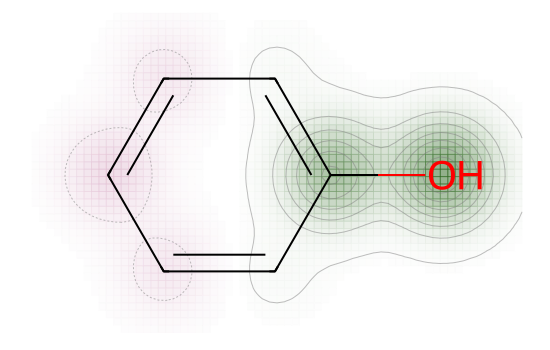

In [3]:
# helper function to draw the explanations as heatmaps
def draw_myerson_values(smiles, myerson_values):
    mol = Chem.MolFromSmiles(smiles)
    d2d = Draw.MolDraw2DSVG(550,350)
    SimilarityMaps.GetSimilarityMapFromWeights(mol, list(myerson_values), d2d)
    d2d.FinishDrawing()
    display(SVG(d2d.GetDrawingText()))

graph = all_data[0].mg
explainer = MyersonExplainer(graph, model)           # you can also use the MyersonSamplingExplainer
my_values = explainer.calculate_all_myerson_values() # in that case call `sample_all_myerson_values`
print(f"prediction={explainer.calculate_prediction():.4f}")
print(f"my_values=\n{my_values}")
print(f"sum(my_values)={sum(my_values):.4f}")
draw_myerson_values(smiles[0], my_values)

We see that the Myerson values add up to the total prediction. For this prediction, the model learned that the not only the oxygen atom contributes, but also the connected carbon atom.
> **⚠️ Warning**
> The `MyersonCalculator` should only be used with Molecules with up to 20 (non-hydrogen) atoms. A handful of atoms more should be fine but will already take longer and at a certain point the program will run out of memory. Use the `MyersonSampler` in these cases.

Note that `myerson.chemprop` also contains explainer for multilabel predictive models: `MyersonClassExplainer` and `MyersonSamplingClassExplainer`. There is also the `--callback myerson` flag which you can use with the `predict` subcommand to calculate explanations for the predictions directly from the command line.  